Filas: 43,848
Columnas: 31

<class 'pandas.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   datetime                         43848 non-null  str    
 1   demand                           43848 non-null  float64
 2   year                             43848 non-null  int64  
 3   month                            43848 non-null  int64  
 4   day                              43848 non-null  int64  
 5   dayofweek                        43848 non-null  int64  
 6   is_weekend                       43848 non-null  int64  
 7   biogas                           43848 non-null  float64
 8   biomasa                          43848 non-null  float64
 9   ciclo_combinado                  43848 non-null  float64
 10  derivados_del_petroleo_o_carbon  43848 non-null  float64
 11  energia_residual                 43848 non-null  float64
 12  e

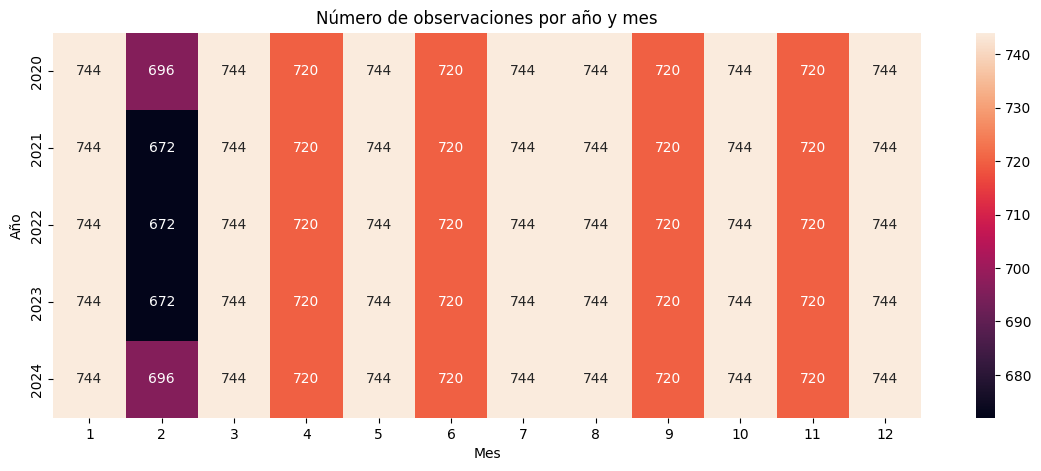

Errores en is_weekend: 0


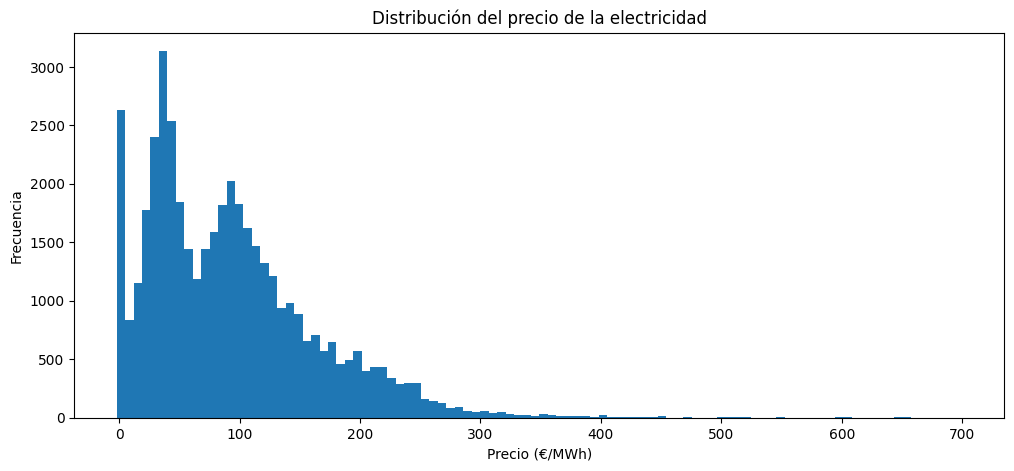

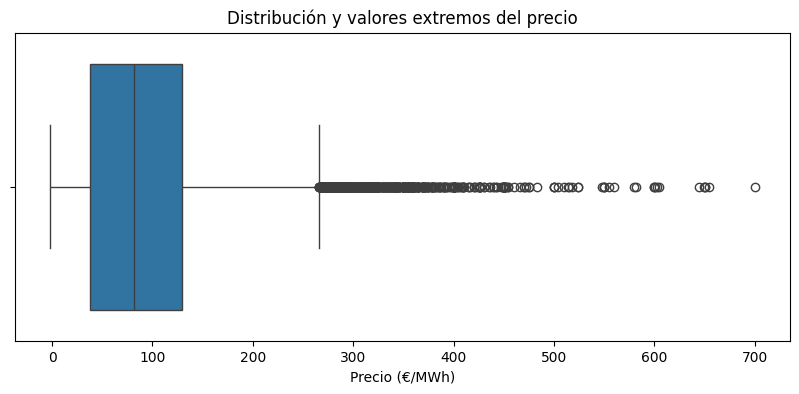

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv(
    "Dataset_Unificado_2020_2024.csv",
    sep=";"
)

df.head()

# =========================
# 1 comprobamos dimensiones:
# =========================

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}\n")

#tipos de los datos:
df.info()

print("\n")

# =========================
# 2 Comprobar el periodo temporal
# =========================

df["datetime"] = pd.to_datetime(df["datetime"])

#fechas de inicio y fin del dataset
print("fechas de inicio y fin del dataset")
print("Fecha mínima:", df["datetime"].min())
print("Fecha máxima:", df["datetime"].max(), "\n")

# Comprobar duplicados
duplicados_datetime = df["datetime"].duplicated().sum()
print("Timestamps(fechas) duplicados:", duplicados_datetime, "\n")


#Calculamos la diferencia entre observaciones:
diferencias = df["datetime"].diff()

diferencias.value_counts().sort_index()
#Normalmente deberías encontrar:  0 days 01:00:00
print(diferencias, "\n")

# =========================
# 3 Comprobar número de observaciones por año y mes
# =========================

print("Número de observaciones por año:")
df.groupby("year").size()

df.groupby("year")["datetime"].agg(["min", "max", "count"])

observaciones_mes = (
    df.groupby(["year", "month"])
      .size()
      .unstack(fill_value=0)
)

observaciones_mes

plt.figure(figsize=(14, 5))

sns.heatmap(
    observaciones_mes,
    annot=True,
    fmt="d"
)

plt.title("Número de observaciones por año y mes")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# =========================
# 4 Comprobar las variables temporales
# =========================

#Podemos comprobar que son coherentes con datetime:
comprobacion = pd.DataFrame({
    "year_correcto": df["year"] == df["datetime"].dt.year,
    "month_correcto": df["month"] == df["datetime"].dt.month,
    "day_correcto": df["day"] == df["datetime"].dt.day,
    "dayofweek_correcto": df["dayofweek"] == df["datetime"].dt.dayofweek,
    "hour_correcto": df["hour"] == df["datetime"].dt.hour
})

comprobacion.sum()

is_weekend_correcto = (
    df["is_weekend"] ==
    df["datetime"].dt.dayofweek.isin([5, 6]).astype(int)
)

print("Errores en is_weekend:", (~is_weekend_correcto).sum())

# =========================
# 5 Estadistica descriptiva
# =========================
#Esto permitira detectar valores sospechosos

#Primero identificamos las variables numéricas:
df.describe().T

#
estadisticas = df.describe().T

#
estadisticas[
    ["mean", "std", "min", "50%", "max"]
].sort_values("std", ascending=False)

# =========================
# 6 Analizar el precio
# =========================

df["price"].describe()

#Histograma
plt.figure(figsize=(12, 5))

plt.hist(df["price"], bins=100)

plt.xlabel("Precio (€/MWh)")
plt.ylabel("Frecuencia")
plt.title("Distribución del precio de la electricidad")

plt.show()

# Diagrama de caja (boxplot) para detectar valores extremos
#Esto es particularmente interesante en electricidad porque el precio
#puede presentar valores extremos y episodios anomalos, incluidos precios
#negativos en determinados mercados/periodos

plt.figure(figsize=(10, 4))

sns.boxplot(x=df["price"])

plt.title("Distribución y valores extremos del precio")
plt.xlabel("Precio (€/MWh)")

plt.show()

# =========================
# 7 Matriz de correlación
# =========================
